### Data Loading and Preprocesing

Imports

In [18]:
import os
import matplotlib.pyplot as plt
import math
from collections import Counter

Set Path and Load Data

In [ ]:
# Set Path 
data_path = "data/de_train.conllu"

# Load data
with open(data_path, "r", encoding = "utf-8") as f:
    lines = f.readlines()

len(lines)

309826

Verify Data

In [5]:
# Verify data
first_twenty = lines[0:20]

for l in first_twenty:
    print(l)

# sent_id = train-s1

# text = Sehr gute Beratung, schnelle Behebung der Probleme, so stelle ich mir Kundenservice vor.

1	Sehr	sehr	ADV	ADV	_	2	advmod	_	_

2	gute	gut	ADJ	ADJA	Case=Nom|Degree=Pos|Gender=Fem|Number=Sing	3	amod	_	_

3	Beratung	Beratung	NOUN	NN	Case=Nom|Gender=Fem|Number=Sing	0	root	_	SpaceAfter=No

4	,	,	PUNCT	$,	_	6	punct	_	_

5	schnelle	schnell	ADJ	ADJA	Case=Nom|Degree=Pos|Gender=Fem|Number=Sing	6	amod	_	_

6	Behebung	Behebung	NOUN	NN	Case=Nom|Gender=Fem|Number=Sing	3	conj	_	_

7	der	der	DET	ART	Case=Gen|Definite=Def|Number=Plur|PronType=Art	8	det	_	_

8	Probleme	Problem	NOUN	NN	Case=Gen|Gender=Neut|Number=Plur	6	nmod	_	SpaceAfter=No

9	,	,	PUNCT	$,	_	11	punct	_	_

10	so	so	ADV	ADV	_	11	advmod	_	_

11	stelle	stellen	VERB	VVFIN	Mood=Ind|Number=Sing|Person=1|Tense=Pres|VerbForm=Fin	3	parataxis	_	_

12	ich	ich	PRON	PPER	Case=Nom|Number=Sing|Person=1|PronType=Prs	11	nsubj	_	_

13	mir	ich	PRON	PRF	Case=Dat|Number=Sing|Person=1|PronType=Prs|Reflex=Yes	11	obl:arg	_	_

14	Kun

Extract Tokens

In [6]:
tokens = [] # List to store tokens
sentences = [] # List to store sentences
current_sentence = [] # Temporary list to build current sentence

# Process each line in the data
for line in lines:
    line = line.strip() # Remove leading/trailing whitespace

    if not line:
        if current_sentence:
            sentences.append(current_sentence) # Add current sentence to sentences list
            current_sentence = [] # Reset current sentence for next one
        
        continue # Skip empty lines

    if line.startswith("#"):
        continue # Skip comment lines

    parts = line.split("\t") # Split line into columns

    if "-" in parts[0]:
        continue # Skip multi-word token lines

    word = parts[1] # Get word from second column
    tokens.append(word) # Add word to tokens list
    current_sentence.append(word) # Add word to current sentence

# Print number of tokens and sentences
len(tokens), len(sentences)

    

(263777, 13813)

Basic Normalization

In [7]:
# Convert all tokens to lowercase
tokens = [t.lower() for t in tokens] 
 # Convert all sentences to lowercase
sentences = [[w.lower() for w in sent] for sent in sentences]

Create Sentence Boundaries

In [8]:
processed_sentences = [] # List to store processed sentences

# Add start and end tokens to each sentence
for sent in sentences:
    processed_sentences.append(["<s>"] + sent + ["</s>"])

Flatten Tokens for N-Gram Model

In [9]:
flat_tokens = [w for s in processed_sentences for w in s] # Flatten list of sentences into single list of tokens

len(flat_tokens) # Number of tokens in processed data

291403

Analyze Vocabulary

In [12]:
vocab = Counter(flat_tokens) # Create vocabulary with token counts

print(f"Vocabulary Size: {len(vocab)}") # Print vocabulary size

# Print 20 most common words in vocabulary
most_common = vocab.most_common(20)
print("20 Most Common Words:")

for w, count in most_common:
    print(f" {w}: {count}")


Vocabulary Size: 47749
20 Most Common Words:
 <s>: 13813
 </s>: 13813
 .: 13210
 ,: 10371
 der: 9021
 die: 7168
 in: 7115
 und: 6504
 dem: 5550
 -: 3419
 von: 3399
 zu: 2963
 den: 2533
 das: 2338
 mit: 2111
 er: 2025
 des: 1972
 ist: 1890
 ": 1803
 ): 1775


Verify Sparsity

In [13]:
rare_words = [w for w, count in vocab.items() if count == 1] # List of words that occur only once
print(f"Number of Words that Only Occur Once: {len(rare_words)}")

Number of Words that Only Occur Once: 33037


Visualize Sparsity

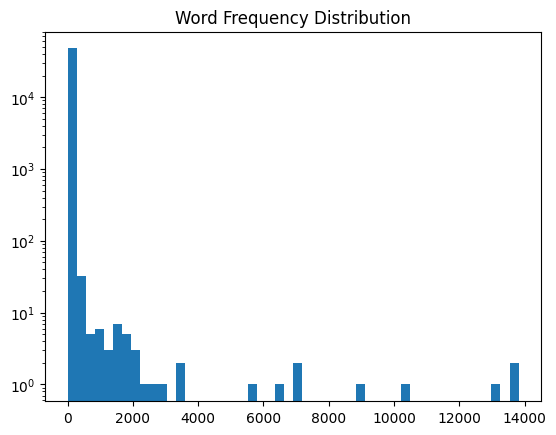

In [15]:
counts = list(vocab.values()) # Get list of token counts

# Plot counts on histogram
plt.hist(counts, bins = 50) # Plot counts on histogram
plt.yscale("log")
plt.title("Word Frequency Distribution")
plt.show()

### Unigram Language Model

Compute Probabilities

In [16]:
# Calculate total flat tokens in processed data
total_tokens = len(flat_tokens)

# Calculate Unigram probabilities
unigram_probs = {w: count / total_tokens for w, count in vocab.items()}

Verify Probabilities

In [17]:
print(sum(unigram_probs.values())) # Verify probabilities sum to 1

1.0


Sentence Log Probability

In [19]:
# Function to calculate log probablility of sentence given unigram prababilities
def sentence_log_prob(sentence, unigram_probs):
    log_prob = 0.0 # Initial log probability

    # Iterate through each word in sentence
    for w in sentence:
        prob = unigram_probs.get(w, 0) # Get unigram probability for word, default to 0 if not found

        if prob > 0:
            log_prob += math.log(prob) # Add log probability of word to total log probability
        else:
            return float("-inf") # If any word has zero probability, return negative infinity
        
    return log_prob # Return total log probability of sentence

Test Sentence Log Probability Function

In [20]:
test_sentence = processed_sentences[0] # Get first processed sentence as test sentence

print(test_sentence)
# Calculate and print log probability of test sentence
print(sentence_log_prob(test_sentence, unigram_probs)) 

['<s>', 'sehr', 'gute', 'beratung', ',', 'schnelle', 'behebung', 'der', 'probleme', ',', 'so', 'stelle', 'ich', 'mir', 'kundenservice', 'vor', '.', '</s>']
-124.74570751669062


Perplexity

In [22]:
# Function to calculate perplexity of sentence given unigram probabilities
def compute_perplexity(tokens, unigram_probs):
    log_prob_sum = 0.0 # Initial log probability sum
    N = len(tokens) # Total number of tokens

    for t in tokens:
        prob = unigram_probs.get(t, 0) # Get unigram probability for token, default to 0 if not found

        if prob > 0:
            log_prob_sum += math.log(prob) # Add log probability of token to total log probability sum
        else:
            return float("inf") # If any token has zero probability, return infinity
        
    return math.exp(-log_prob_sum / N) # Return perplexity calculated from log probability sum and total tokens

Run Compute Perplexity Function

In [23]:
# Calculate perplexity of processed data using unigram probabilities
pp = compute_perplexity(flat_tokens, unigram_probs) 

print(f"Perplexity of Processed Data: {pp}")

Perplexity of Processed Data: 1352.9234507548945
